In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ironwolf437/laptop-price-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/zadyra/.cache/kagglehub/datasets/ironwolf437/laptop-price-dataset/versions/1


In [16]:
print(os.listdir(path))

['laptop_price - dataset.csv']


In [17]:
df = pd.read_csv(os.path.join(path, "laptop_price - dataset.csv"))
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [18]:
df.describe()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), object(10)
me

In [20]:
df['OpSys'].value_counts()

OpSys
Windows 10      1048
No OS             66
Linux             58
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [21]:
df['GPU_Type'].value_counts()

GPU_Type
HD Graphics 620     280
HD Graphics 520     181
UHD Graphics 620     68
GeForce GTX 1050     66
GeForce GTX 1060     48
                   ... 
Graphics 620          1
Radeon R5 520         1
Radeon R7             1
HD Graphics 540       1
Mali T860 MP4         1
Name: count, Length: 106, dtype: int64

In [24]:
df.isna().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [28]:
#Insights:
# 1. RAM; 2. CPU-Freq;

In [26]:
df['Price (Euro)']

0       1339.69
1        898.94
2        575.00
3       2537.45
4       1803.60
         ...   
1270     638.00
1271    1499.00
1272     229.00
1273     764.00
1274     369.00
Name: Price (Euro), Length: 1275, dtype: float64


===== Price (Euro) by Company =====
           count   median         mean
Company                               
Razer          7  2899.00  3346.142857
LG             3  2099.00  2099.000000
Samsung        9  1649.00  1413.444444
MSI           54  1599.00  1728.908148
Microsoft      6  1569.50  1612.308333
Google         3  1559.00  1677.666667
Huawei         2  1424.00  1424.000000
Apple         21  1339.69  1564.198571
Toshiba       48  1211.50  1267.812500
Xiaomi         4  1099.45  1133.462500
Asus         152  1049.45  1123.829737
Dell         291   999.00  1199.225120
HP           268   979.00  1080.314664
Lenovo       289   899.00  1093.862215
Fujitsu        3   739.00   729.000000
Acer         101   572.00   633.464455
Mediacom       7   265.00   295.000000
Chuwi          3   248.90   314.296667
Vero           4   206.85   217.425000

===== Price (Euro) by TypeName =====
                    count  median         mean
TypeName                                      
Workstation 

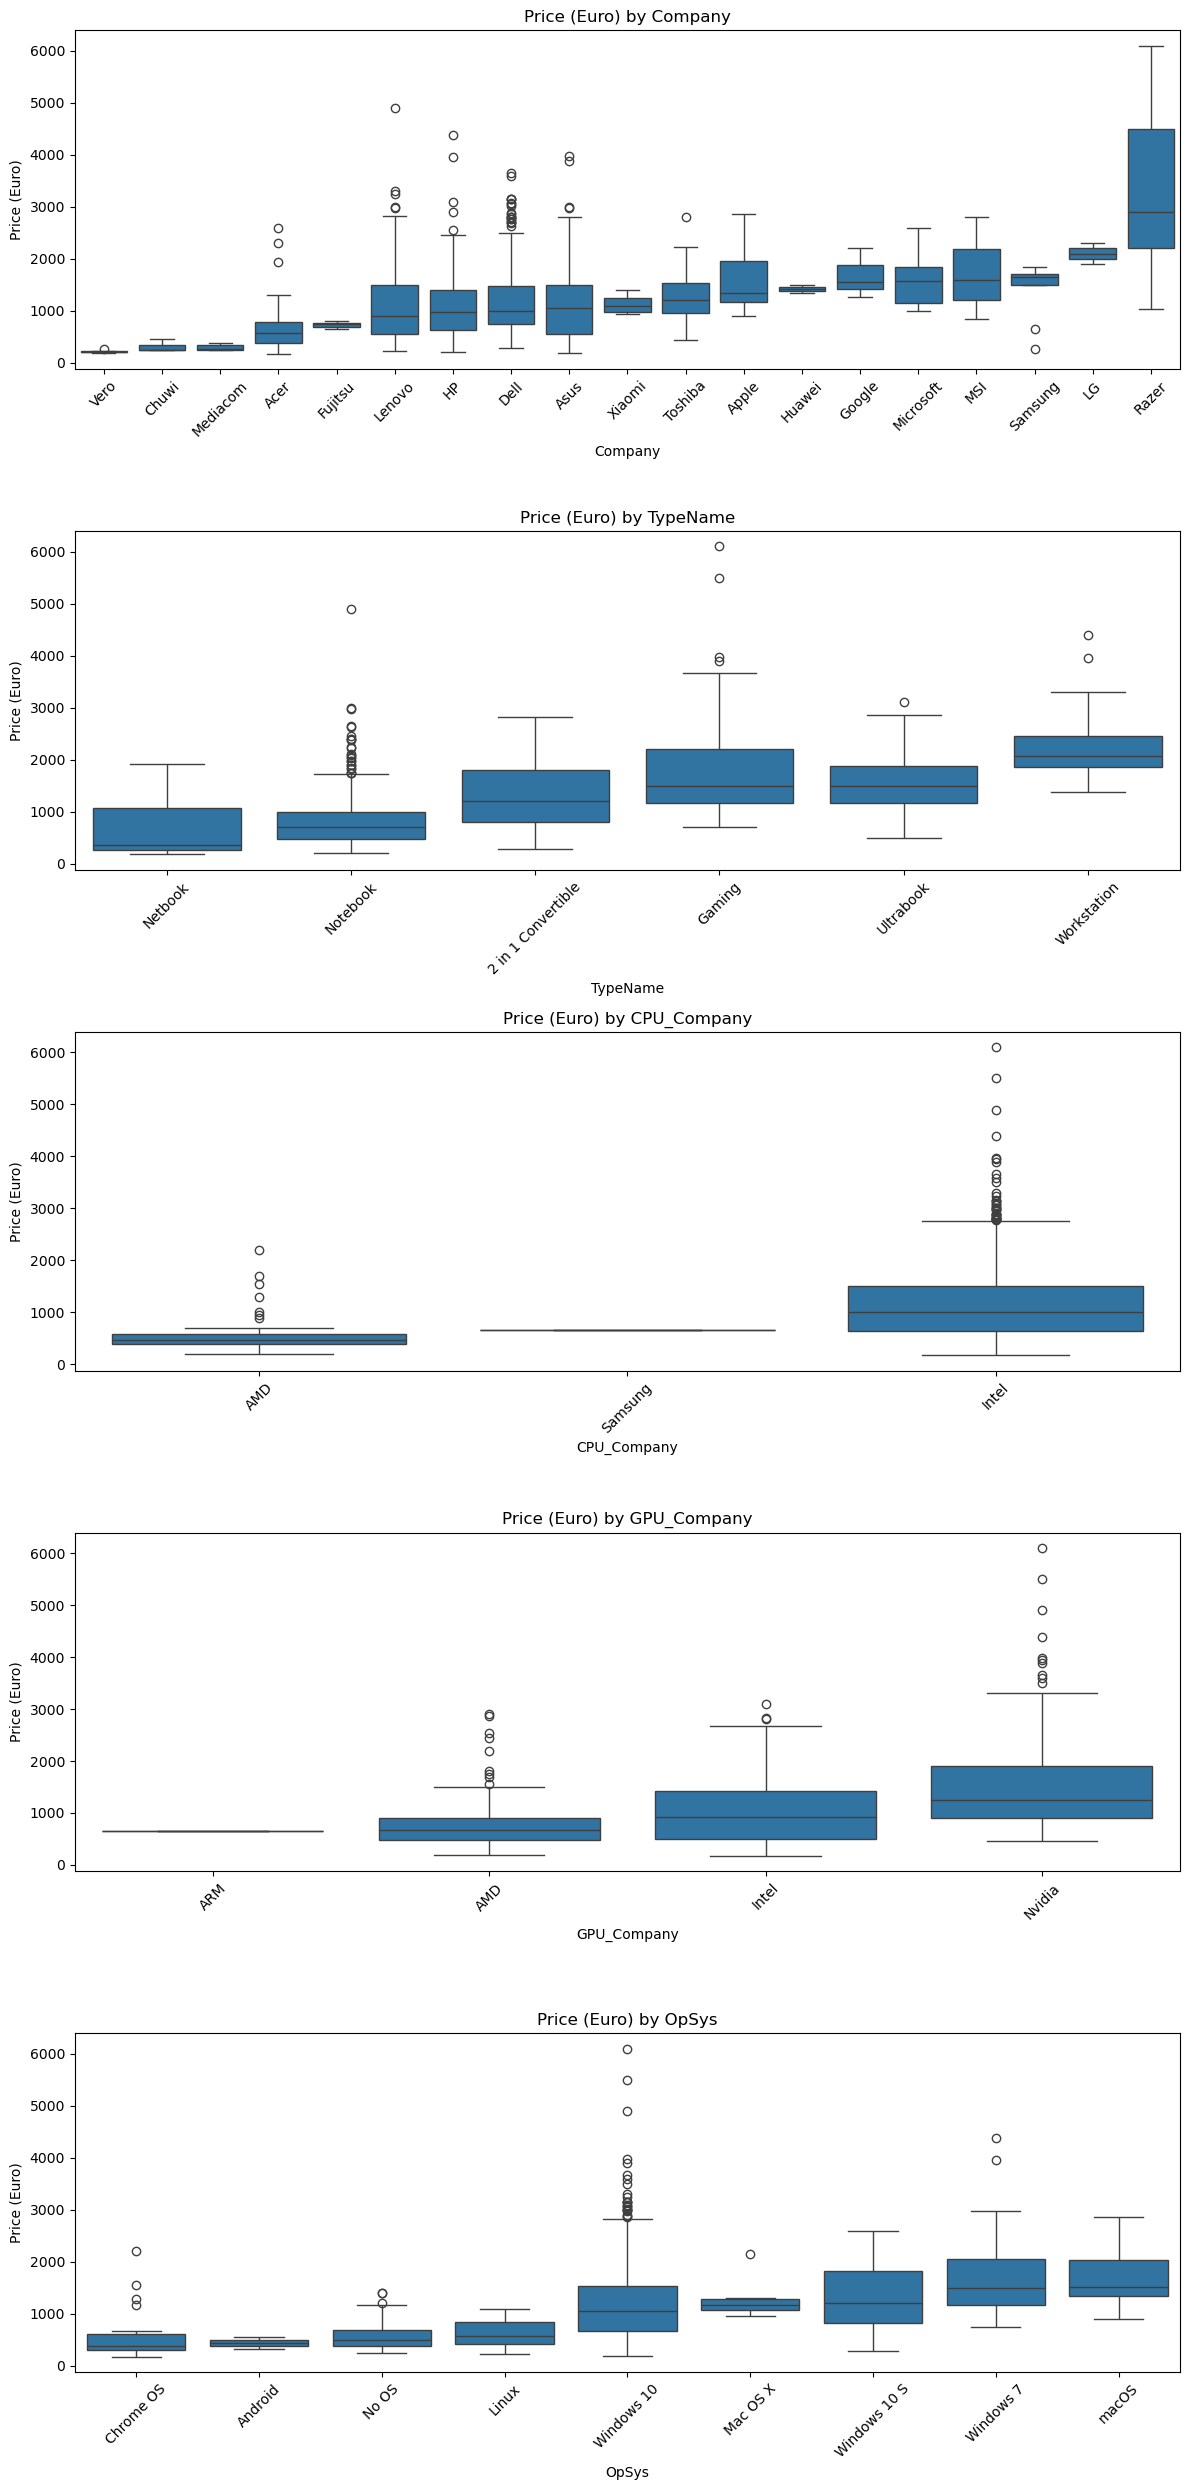

In [33]:
# Categorical columns vs Price: groupby summary + boxplots
# Use low-cardinality categoricals (high-cardinality ones like GPU_Type/CPU_Type
# have too many levels to read as boxplots).
cat_cols = ['Company', 'TypeName', 'CPU_Company', 'GPU_Company', 'OpSys']

# Ranked median/mean price per category — quick numeric view of which levels matter
for col in cat_cols:
    print(f'\n===== Price (Euro) by {col} =====')
    print(df.groupby(col)['Price (Euro)']
            .agg(['count', 'median', 'mean'])
            .sort_values('median', ascending=False))

# Boxplots (categories ordered by median price for readability)
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 5 * len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    order = df.groupby(col)['Price (Euro)'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='Price (Euro)', order=order, ax=ax)
    ax.set_title(f'Price (Euro) by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [30]:
X = df.drop(['Price (Euro)'], axis=1)

In [31]:
X

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel,Core i7 6500U,2.5,4,128GB SSD,Intel,HD Graphics 520,Windows 10,1.80
1271,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel,Core i7 6500U,2.5,16,512GB SSD,Intel,HD Graphics 520,Windows 10,1.30
1272,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel,Celeron Dual Core N3050,1.6,2,64GB Flash Storage,Intel,HD Graphics,Windows 10,1.50
1273,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel,Core i7 6500U,2.5,6,1TB HDD,AMD,Radeon R5 M330,Windows 10,2.19


In [32]:
y = df['Price (Euro)']
y

0       1339.69
1        898.94
2        575.00
3       2537.45
4       1803.60
         ...   
1270     638.00
1271    1499.00
1272     229.00
1273     764.00
1274     369.00
Name: Price (Euro), Length: 1275, dtype: float64

<Axes: >

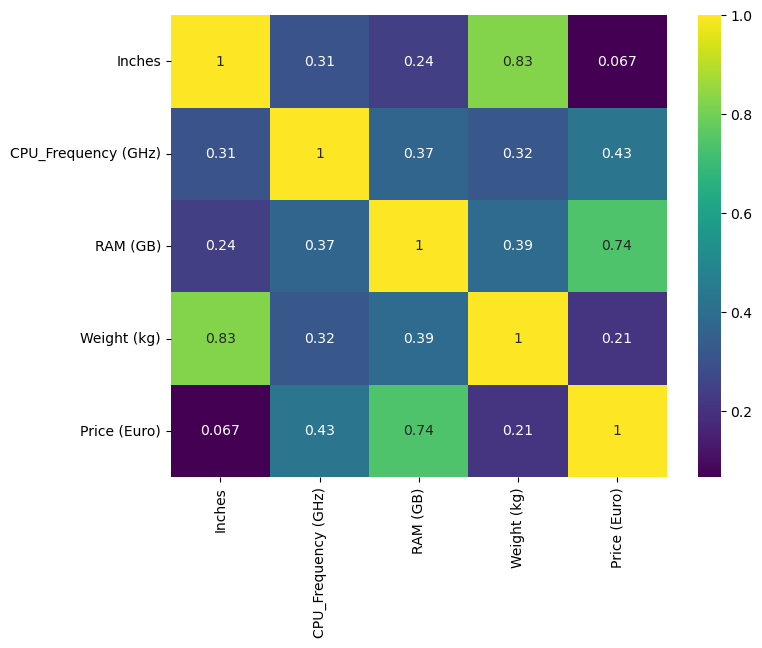

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),cmap='viridis',annot=True)

Correlation with Price (top continuous features):
RAM (GB)               0.740
SSD_GB                 0.670
Screen_W               0.552
Screen_H               0.549
PPI                    0.470
CPU_Frequency (GHz)    0.429
Weight (kg)            0.212
Total_Storage_GB       0.157

Top 3 chosen for scatter: ['RAM (GB)', 'SSD_GB', 'Screen_W']


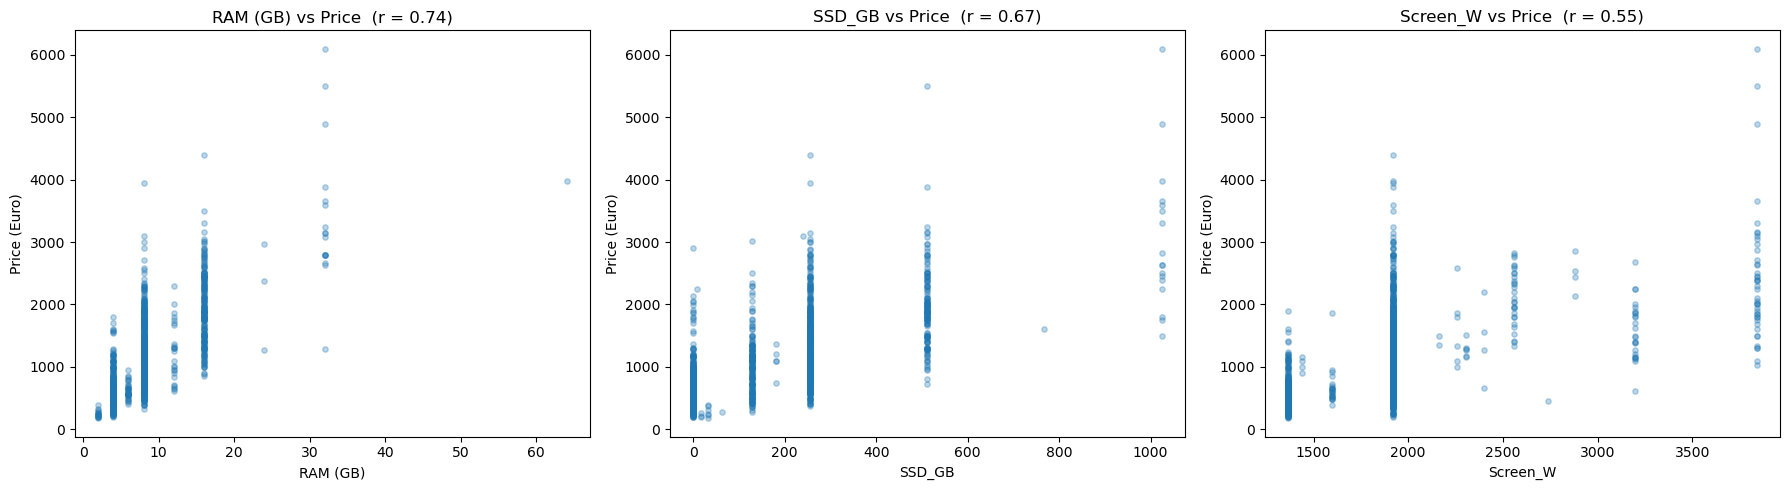


--- Diagnostics ---
RAM (GB)       skew=+2.70  IQR_outliers= 219  zeros=   0  missing=0
SSD_GB         skew=+1.43  IQR_outliers=  18  zeros= 438  missing=0
Screen_W       skew=+2.21  IQR_outliers= 437  zeros=   0  missing=0
Price (Euro)   skew=+1.51  IQR_outliers=  28  zeros=   0  missing=0


In [69]:
from scipy import stats

target = y  # Price (Euro)

# Correlation of every encoded feature with the target.
# Restrict to truly continuous columns (>2 unique values) so we don't pick 0/1 dummies,
# which aren't meaningful as scatter plots.
continuous = [c for c in X_encoded.columns
              if X_encoded[c].dtype != bool and X_encoded[c].nunique() > 2]
corr = X_encoded[continuous].corrwith(target)

top3 = corr.abs().sort_values(ascending=False).head(3).index.tolist()
print("Correlation with Price (top continuous features):")
print(corr.reindex(corr.abs().sort_values(ascending=False).index).head(8).round(3).to_string())
print("\nTop 3 chosen for scatter:", top3)

# Scatter plots: feature vs Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3):
    ax.scatter(X_encoded[feat], target, alpha=0.3, s=15)
    ax.set_xlabel(feat); ax.set_ylabel('Price (Euro)')
    ax.set_title(f'{feat} vs Price  (r = {corr[feat]:.2f})')
plt.tight_layout(); plt.show()

# Diagnostics: skew, IQR-outliers, structural zeros, missing values
print("\n--- Diagnostics ---")
for feat in top3 + ['Price (Euro)']:
    s = target if feat == 'Price (Euro)' else X_encoded[feat]
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3 - q1
    out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    print(f"{feat:14} skew={s.skew():+.2f}  IQR_outliers={out:>4}  "
          f"zeros={(s == 0).sum():>4}  missing={s.isna().sum()}")

## Encoding & feature extraction (before train/test split)

Turn the raw feature matrix `X` into an all-numeric matrix a regression model can consume.

**1. Feature extraction from messy text columns**
- `Memory` (e.g. `"128GB SSD +  1TB HDD"`) → numeric capacity per storage type: `SSD_GB`, `HDD_GB`, `Flash_GB`, `Hybrid_GB`, plus `Total_Storage_GB`. TB is converted to GB (×1024).
- `ScreenResolution` (e.g. `"IPS Panel Retina Display 2560x1600"`) → `Screen_W`, `Screen_H`, `PPI` (pixel density, using `Inches`), and binary flags `Touchscreen`, `IPS`, `Retina`.

**2. High-cardinality categoricals** — `CPU_Type` (93 levels) and `GPU_Type` (106 levels) are lumped: any level appearing < 10 times becomes `"Other"`, so one-hot doesn't explode into hundreds of sparse columns. `Product` (618 near-unique values) is **dropped** — it's an identifier, not a generalizable feature.

**3. One-hot encoding** — `Company`, `TypeName`, `CPU_Company`, `GPU_Company`, `OpSys` + the lumped `CPU_Type`/`GPU_Type` via `pd.get_dummies(..., drop_first=True)`.

**Why this is safe to do before the split:** every transformation here is *deterministic* and *does not look at the target* `y` — string parsing, fixed thresholds, and one-hot just restructure the inputs. (Operations that *learn* from data — target/frequency encoding, scaling, imputation statistics — must be fit on the train split only to avoid leakage. We have none of those here.) Doing one-hot on the full frame also guarantees train and test share identical columns.

In [66]:
import re

def to_gb(size_str):
    """'1TB' -> 1024.0, '256GB' -> 256.0"""
    m = re.match(r'([\d.]+)\s*(TB|GB)', size_str.strip())
    val, unit = float(m.group(1)), m.group(2)
    return val * 1024 if unit == 'TB' else val

def parse_memory(mem):
    """Split 'X + Y' storage strings into capacity per type (GB)."""
    out = {'SSD_GB': 0.0, 'HDD_GB': 0.0, 'Flash_GB': 0.0, 'Hybrid_GB': 0.0}
    for part in mem.split('+'):
        gb = to_gb(part)
        if   'SSD'    in part: out['SSD_GB']    += gb
        elif 'HDD'    in part: out['HDD_GB']    += gb
        elif 'Flash'  in part: out['Flash_GB']  += gb
        elif 'Hybrid' in part: out['Hybrid_GB'] += gb
    return pd.Series(out)

def lump_rare(series, threshold=10):
    """Collapse categories appearing < threshold times into 'Other'."""
    keep = series.value_counts().loc[lambda c: c >= threshold].index
    return series.where(series.isin(keep), 'Other')

def encode_features(X):
    X = X.copy()

    # --- Memory -> numeric storage capacities ---
    X = pd.concat([X, X['Memory'].apply(parse_memory)], axis=1)
    X['Total_Storage_GB'] = X[['SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB']].sum(axis=1)

    # --- ScreenResolution -> dimensions, PPI, panel flags ---
    res = X['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)
    X['Screen_W'], X['Screen_H'] = res[0], res[1]
    X['PPI'] = np.sqrt(X['Screen_W']**2 + X['Screen_H']**2) / X['Inches']
    X['Touchscreen'] = X['ScreenResolution'].str.contains('Touchscreen').astype(int)
    X['IPS']         = X['ScreenResolution'].str.contains('IPS').astype(int)
    X['Retina']      = X['ScreenResolution'].str.contains('Retina').astype(int)

    # --- Tame high-cardinality categoricals; drop the identifier column ---
    X['CPU_Type'] = lump_rare(X['CPU_Type'])
    X['GPU_Type'] = lump_rare(X['GPU_Type'])
    X = X.drop(columns=['Memory', 'ScreenResolution', 'Product'])

    # --- One-hot encode the remaining categoricals ---
    onehot_cols = ['Company', 'TypeName', 'CPU_Company', 'GPU_Company',
                   'OpSys', 'CPU_Type', 'GPU_Type']
    X = pd.get_dummies(X, columns=onehot_cols, drop_first=True)
    return X

X_encoded = encode_features(X)
print("Encoded shape:", X_encoded.shape)
print("Any non-numeric columns?:",
      [c for c in X_encoded.columns if not np.issubdtype(X_encoded[c].dtype, np.number) and X_encoded[c].dtype != bool])
print("Any NaNs?:", int(X_encoded.isna().sum().sum()))
X_encoded

Encoded shape: (1275, 98)
Any non-numeric columns?: []
Any NaNs?: 0


,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,Total_Storage_GB,Screen_W,...,GPU_Type_HD Graphics 520,GPU_Type_HD Graphics 615,GPU_Type_HD Graphics 620,GPU_Type_Other,GPU_Type_Radeon 520,GPU_Type_Radeon 530,GPU_Type_Radeon R5,GPU_Type_Radeon R5 M430,GPU_Type_Radeon R7 M445,GPU_Type_UHD Graphics 620
0,13.3,2.3,8,1.37,128.0,0.0,0.0,0.0,128.0,2560.0,...,False,False,False,True,False,False,False,False,False,False
1,13.3,1.8,8,1.34,0.0,0.0,128.0,0.0,128.0,1440.0,...,False,False,False,True,False,False,False,False,False,False
2,15.6,2.5,8,1.86,256.0,0.0,0.0,0.0,256.0,1920.0,...,False,False,True,False,False,False,False,False,False,False
3,15.4,2.7,16,1.83,512.0,0.0,0.0,0.0,512.0,2880.0,...,False,False,False,True,False,False,False,False,False,False
4,13.3,3.1,8,1.37,256.0,0.0,0.0,0.0,256.0,2560.0,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,14.0,2.5,4,1.80,128.0,0.0,0.0,0.0,128.0,1920.0,...,True,False,False,False,False,False,False,False,False,False
1271,13.3,2.5,16,1.30,512.0,0.0,0.0,0.0,512.0,3200.0,...,True,False,False,False,False,False,False,False,False,False
1272,14.0,1.6,2,1.50,0.0,0.0,64.0,0.0,64.0,1366.0,...,False,False,False,False,False,False,False,False,False,False
1273,15.6,2.5,6,2.19,0.0,1024.0,0.0,0.0,1024.0,1366.0,...,False,False,False,True,False,False,False,False,False,False


In [38]:
## Train Test Split

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [57]:
#PPI - pixels per inch
#X['PPI'] = np.sqrt(X['Screen_W']**2 + X['Screen_H']**2) / X['Inches']al 
#Total storage matters the least because the type is the most important: SSD (+0.6) HDD (-0.09)

## Pipeline: SimpleImputer(median) → StandardScaler → LinearRegression

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Pipeline: median imputation -> standardize -> linear regression
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression()),
])

# Fit on TRAIN only (imputer/scaler learn their statistics from the training set)
pipe.fit(X_train, y_train)

# Predict and evaluate on the TEST set only
y_pred = pipe.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("Test-set performance")
print(f"MAE : {mae:.2f} Euro")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f} Euro")
print(f"R2  : {r2:.4f}")

Test-set performance
MAE : 224.04 Euro
MSE : 96578.15
RMSE: 310.77 Euro
R2  : 0.8054


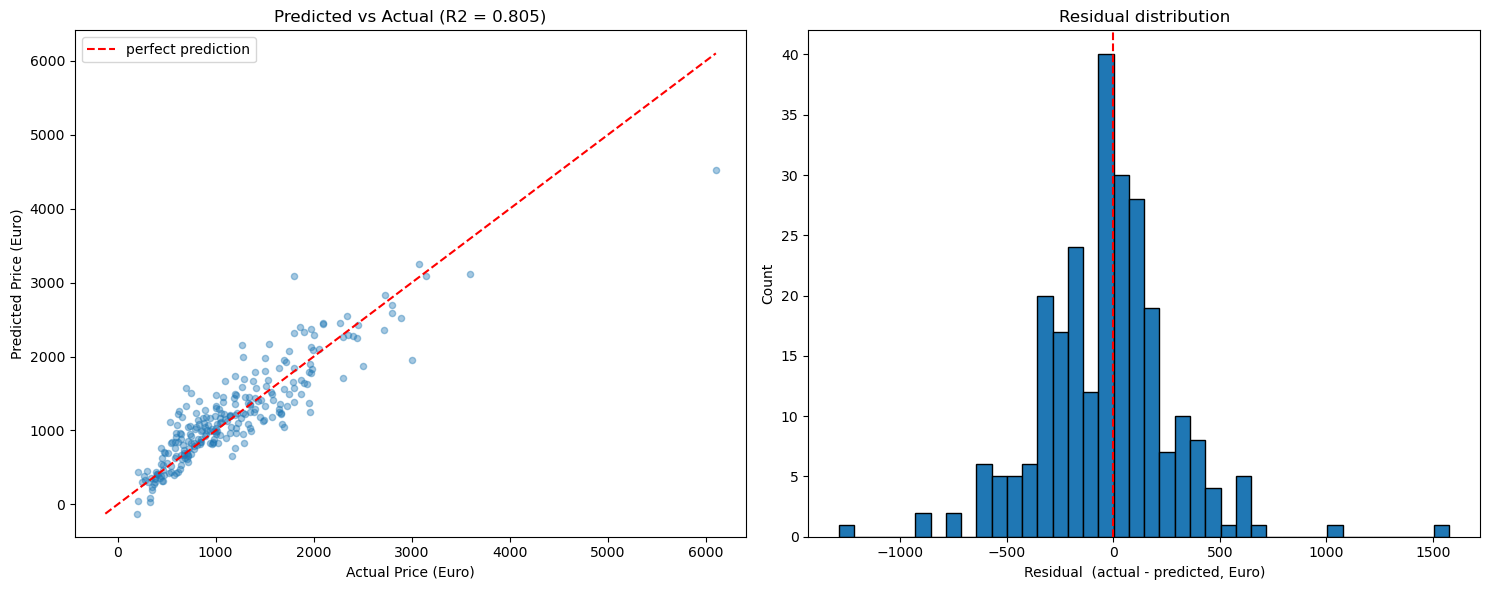

In [59]:
# Diagnostic plots (test set): predicted vs actual, and residual histogram
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.4, s=20)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', label='perfect prediction')
axes[0].set_xlabel('Actual Price (Euro)')
axes[0].set_ylabel('Predicted Price (Euro)')
axes[0].set_title(f'Predicted vs Actual (R2 = {r2:.3f})')
axes[0].legend()

# Histogram of residuals
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual  (actual - predicted, Euro)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

## Model comparison: Linear vs Polynomial(deg 2) vs Ridge

Same train/test split (`test_size=0.2, random_state=42`). All three are pipelines so scaling is fit on the train fold only.

⚠️ Polynomial degree 2 on 98 features expands to ~5,000 columns while we only have 1,020 training rows (p ≫ n), so plain OLS on top of it **overfits catastrophically** — this is intentional, to contrast with regularization.

In [67]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso

# Four models on the SAME X_train/X_test/y_train/y_test from the split above
models = {
    'Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ]),
    'Polynomial (deg 2)': Pipeline([
        ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ]),
    'Ridge (alpha=100)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=100)),
    ]),
    'Lasso (alpha=10)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=10, max_iter=10000)),
    ]),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rows.append({
        'Model':      name,
        'Test RMSE':  np.sqrt(mean_squared_error(y_test, pred)),
        'Test R2':    r2_score(y_test, pred),
        'Train R2':   m.score(X_train, y_train),   # for under/overfit context
    })

results = pd.DataFrame(rows).set_index('Model')
results.round(3)

,Test RMSE,Test R2,Train R2
Model,,,
Linear,310.770,0.805,0.836
Polynomial (deg 2),2022439.474,-8240856.883,0.994
Ridge (alpha=100),304.434,0.813,0.828
Lasso (alpha=10),303.855,0.814,0.813


Best  model: Lasso (alpha=10)
Worst model: Polynomial (deg 2)


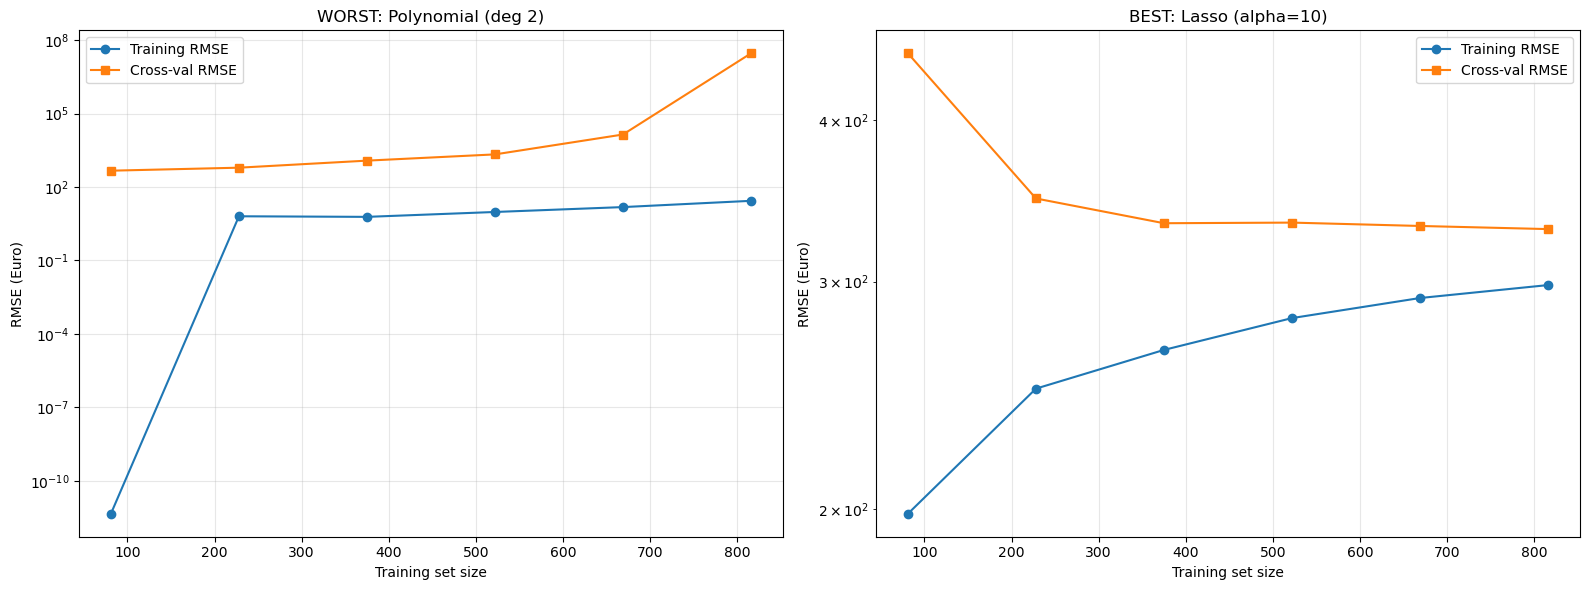

In [63]:
from sklearn.model_selection import learning_curve

# Pick best & worst by Test R2 from the table above
best_name  = results['Test R2'].idxmax()
worst_name = results['Test R2'].idxmin()
print(f"Best  model: {best_name}")
print(f"Worst model: {worst_name}")

def plot_learning_curve(ax, estimator, X, yv, title):
    sizes, train_sc, val_sc = learning_curve(
        estimator, X, yv, cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
    train_rmse = -train_sc.mean(axis=1)   # flip sign back to positive RMSE
    val_rmse   = -val_sc.mean(axis=1)
    ax.plot(sizes, train_rmse, 'o-', label='Training RMSE')
    ax.plot(sizes, val_rmse,   's-', label='Cross-val RMSE')
    ax.set_xlabel('Training set size'); ax.set_ylabel('RMSE (Euro)')
    ax.set_yscale('log')   # log scale: train & CV RMSE can differ by orders of magnitude
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_learning_curve(axes[0], models[worst_name], X_train, y_train, f'WORST: {worst_name}')
plot_learning_curve(axes[1], models[best_name],  X_train, y_train, f'BEST: {best_name}')
plt.tight_layout(); plt.show()

In [64]:
# Lasso's feature selection: how many coefficients did it drive to exactly 0?
lasso = models['Lasso (alpha=10)'].named_steps['model']
coefs = pd.Series(lasso.coef_, index=X_train.columns)

n_total = len(coefs)
n_zero  = int((coefs == 0).sum())
n_kept  = n_total - n_zero
print(f"Total features      : {n_total}")
print(f"Dropped (coef = 0)  : {n_zero}")
print(f"Kept   (coef != 0)  : {n_kept}")

print("\nTop 15 surviving features by |coefficient| (price impact in Euro):")
print(coefs[coefs != 0].reindex(coefs.abs().sort_values(ascending=False).index)
            .dropna().head(15).round(1).to_string())

Total features      : 98
Dropped (coef = 0)  : 43
Kept   (coef != 0)  : 55

Top 15 surviving features by |coefficient| (price impact in Euro):
RAM (GB)                     227.8
SSD_GB                       131.4
Screen_H                     104.2
CPU_Frequency (GHz)          103.3
TypeName_Notebook            -99.3
GPU_Type_GeForce GTX 1070     81.4
TypeName_Workstation          80.7
CPU_Company_Intel             79.0
OpSys_Windows 7               59.3
Company_Razer                 52.6
OpSys_No OS                  -41.3
TypeName_Ultrabook            27.6
GPU_Type_HD Graphics 515      23.3
GPU_Type_HD Graphics 400     -22.0
GPU_Type_GeForce GTX 1060     22.0


In [65]:
# --- Best model: error in context + worst predictions ---
best_name = results['Test R2'].idxmax()
best_model = models[best_name]
best_rmse = results.loc[best_name, 'Test RMSE']

y_mean, y_std = y.mean(), y.std()
print(f"Best model: {best_name}")
print(f"Test RMSE        : {best_rmse:.0f} Euro")
print(f"Target mean      : {y_mean:.0f} Euro   -> RMSE is {best_rmse/y_mean*100:.0f}% of the mean price")
print(f"Target std dev   : {y_std:.0f} Euro   -> RMSE is {best_rmse/y_std*100:.0f}% of the std (i.e. ~{best_rmse/y_std:.2f} sigma)")

# Residuals on the test set
pred = best_model.predict(X_test)
resid = y_test - pred

worst = (pd.DataFrame({
            'Actual':    y_test,
            'Predicted': pred.round(0),
            'Residual':  resid.round(0),
         })
         .assign(AbsResidual=lambda d: d['Residual'].abs())
         .sort_values('AbsResidual', ascending=False)
         .head(5))

# Attach the real specs of those laptops for interpretation
specs = df.loc[worst.index, ['Company', 'TypeName', 'RAM (GB)', 'Memory', 'GPU_Type']]
worst_full = specs.join(worst[['Actual', 'Predicted', 'Residual']])
print("\n5 largest residuals (worst predictions):")
worst_full

Best model: Lasso (alpha=10)
Test RMSE        : 304 Euro
Target mean      : 1135 Euro   -> RMSE is 27% of the mean price
Target std dev   : 701 Euro   -> RMSE is 43% of the std (i.e. ~0.43 sigma)

5 largest residuals (worst predictions):


,Company,TypeName,RAM (GB),Memory,GPU_Type,Actual,Predicted,Residual
196,Razer,Gaming,32,1TB SSD,GeForce GTX 1080,6099.0,4235.0,1864.0
816,Razer,Ultrabook,16,512GB SSD,HD Graphics 620,1799.0,3025.0,-1226.0
247,Asus,Gaming,16,256GB SSD,GeForce GTX 1080,2999.0,1811.0,1188.0
707,Lenovo,Workstation,16,512GB SSD,Quadro M520M,1855.0,2743.0,-888.0
494,Asus,Gaming,24,256GB SSD + 1TB HDD,GeForce GTX 965M,1269.0,2068.0,-799.0


In [68]:
# --- Coefficients of the Linear Regression (interpretation) ---
# Read from the SCALED model, so magnitudes are comparable:
# each value = Euro change in price per +1 standard deviation of that feature.
lin = models['Linear']                       # StandardScaler + LinearRegression pipeline
coef = pd.Series(lin.named_steps['model'].coef_, index=X_train.columns)
intercept = lin.named_steps['model'].intercept_

print(f"Intercept (b0): {intercept:.0f} Euro")
print("(predicted price for an 'average' laptop, since features are standardized)\n")

print("TOP 10 features that RAISE the price:")
print(coef.sort_values(ascending=False).head(10).round(1).to_string())

print("\nTOP 10 features that LOWER the price:")
print(coef.sort_values().head(10).round(1).to_string())

# Multicollinearity made visible: Screen_W / Screen_H / PPI are ~0.99 correlated,
# so plain OLS splits the weight between them in an unstable way.
print("\nCollinear screen features (unstable weights):")
print(coef[['Screen_W', 'Screen_H', 'PPI']].round(1).to_string())

Intercept (b0): 1125 Euro
(predicted price for an 'average' laptop, since features are standardized)

TOP 10 features that RAISE the price:
RAM (GB)                     202.3
CPU_Frequency (GHz)          183.1
GPU_Type_HD Graphics 620     166.4
GPU_Type_HD Graphics 520     158.7
Screen_W                     141.6
CPU_Company_Intel            131.1
SSD_GB                       115.6
OpSys_Windows 7               98.4
Company_HP                    88.7
GPU_Type_GeForce GTX 1070     87.9

TOP 10 features that LOWER the price:
TypeName_Notebook           -122.8
GPU_Company_Intel           -117.0
TypeName_Gaming             -103.4
PPI                          -84.8
CPU_Type_Core i5 7200U       -68.3
CPU_Type_Core i3 7100U       -55.3
CPU_Type_Core i7 7500U       -53.4
CPU_Type_Core i7 6500U       -47.9
CPU_Type_Core i3 6006U       -43.6
GPU_Type_GeForce GTX 1050    -39.5

Collinear screen features (unstable weights):
Screen_W    141.6
Screen_H     30.2
PPI         -84.8
